# Multiscale Equilibria and Jacobian Regularization

A multiscale equilibrium solves several coupled states at once. In a compact
two-scale notation,

$$
z^\star=(z_\ell^\star,z_h^\star),
\qquad
z^\star=f_\theta(z^\star,x).
$$

The tutorial block uses

$$
z_\ell^+=\tanh(S_\ell(x)+A_{\ell\ell}z_\ell+A_{h\ell}z_h),
$$

$$
z_h^+=\tanh(S_h(x)+A_{hh}z_h+A_{\ell h}z_\ell).
$$

Jacobian regularization adds a penalty such as

$$
\lambda_J\|J_f(z^\star)\|_F^2
$$

to encourage stable local dynamics.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[5]](https://jseluis.github.io/silva-networks/paper/references/#ref-5), [[6]](https://jseluis.github.io/silva-networks/paper/references/#ref-6), [[14]](https://jseluis.github.io/silva-networks/paper/references/#ref-14). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import resolve_device, SolverConfig

torch.manual_seed(7)
np.random.seed(7)
device = resolve_device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Two Coupled Scales

The state is stored as one tensor for solver compatibility, then split into
low and high scales when the transition is evaluated.

In [3]:
from silva_networks import (
    silva_jacobian_regularization_loss,
    silva_multiscale_deq_block,
    stability_report,
)

x = torch.randn(6, 4, device=device)
block = silva_multiscale_deq_block(
    in_dim=4,
    low_dim=3,
    high_dim=5,
    config=SolverConfig(solver="anderson", max_iter=8, alpha=0.6, history=3),
).to(device)

result = block(x, return_result=True)
z_low, z_high = block.split_state(result.z)
result.z.shape, z_low.shape, z_high.shape, result.residual

(torch.Size([6, 8]),
 torch.Size([6, 3]),
 torch.Size([6, 5]),
 0.010082932189106941)

## Hutchinson Estimate

For a random Rademacher vector $v$,

$$
\mathbb E\|J_f^\top v\|_2^2=\|J_f\|_F^2.
$$

The estimator uses VJP calls and does not materialize the full Jacobian.

In [4]:
penalty = silva_jacobian_regularization_loss(
    lambda z: block.transition(z, x),
    result.z,
    samples=2,
    squared=True,
    weight=0.01,
)
penalty.detach().cpu()

tensor(0.0542)

## Stability Report

The residual and spectral radius summarize the fixed point locally:

$$
\rho(J_f(z^\star))<1
$$

is the familiar contraction-style target for stable Picard dynamics.

In [5]:
report = stability_report(lambda z: block.transition(z, x), result.z, samples=1, iters=6)
report

StabilityReport(residual=0.0037503144703805447, spectral_radius=0.3704800307750702, jacobian_norm_estimate=2.8830931186676025, samples=1)

## Training Loss with a Jacobian Penalty

This cell separates the task loss from the regularizer so the effect of the
penalty is visible in the output.

In [6]:
head = torch.nn.Linear(block.state_dim, 2).to(device)
y = torch.randint(0, 2, (x.shape[0],), device=device)
optim = torch.optim.Adam(list(block.parameters()) + list(head.parameters()), lr=0.01)

losses = []
penalties = []
for _ in range(4):
    optim.zero_grad()
    solve = block(x, return_result=True)
    logits = head(solve.z)
    task_loss = torch.nn.functional.cross_entropy(logits, y)
    jac_loss = silva_jacobian_regularization_loss(lambda z: block.transition(z, x), solve.z, samples=1, weight=0.01)
    loss = task_loss + jac_loss
    loss.backward()
    optim.step()
    losses.append(float(task_loss.detach().cpu()))
    penalties.append(float(jac_loss.detach().cpu()))

losses, penalties

([0.5598542094230652,
  0.5245211720466614,
  0.49192532896995544,
  0.4611372947692871],
 [0.06476221233606339,
  0.06196095794439316,
  0.0524652898311615,
  0.07055415213108063])

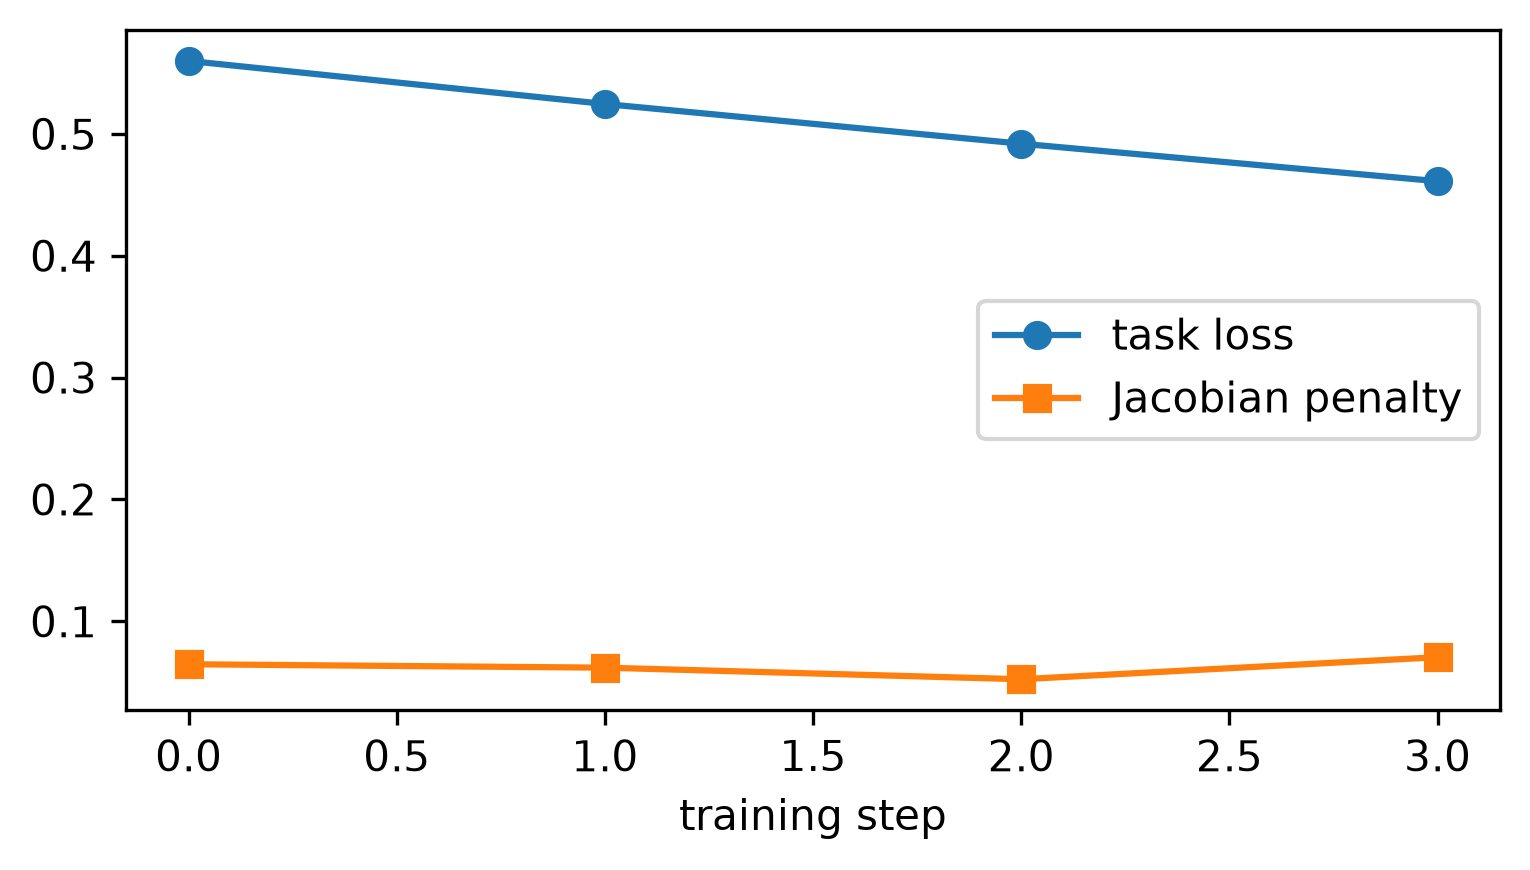

In [7]:
plt.figure(figsize=(5.2, 3.0))
plt.plot(losses, marker="o", label="task loss")
plt.plot(penalties, marker="s", label="Jacobian penalty")
plt.xlabel("training step")
plt.legend()
plt.tight_layout()

## Citation and Sources

If this package or notebook is used, cite the software repository:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.1.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770098
```

When the work is connected to the SILVA methodology, cite the SILVA Networks
paper as well:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Background sources:

- Deep Implicit Layers tutorial: https://implicit-layers-tutorial.org/
- LocusLab DEQ repository: https://github.com/locuslab/deq
- Deep Equilibrium Models: https://arxiv.org/abs/1909.01377
- Multiscale Deep Equilibrium Models: https://arxiv.org/abs/2006.08656
- Stabilizing Equilibrium Models by Jacobian Regularization: https://arxiv.org/abs/2106.14342

The notebook is adapted to the `silva_networks` public API. It links to the
sources above and keep the examples package-native.

## From 06 Mdeq Jacobian Regularization to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the converged latent state z_star |
| Condition | differentiable parameters and external inputs |
| Repeated computation | the map whose Jacobian defines I - J_z f |
| Required invariants | agreement of dense, JVP, VJP, and matrix-free products |
| Replaceable components | transition, Jacobian product, linear solver, regularizer, and loss |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [8]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**adjoint residual and gradient error against explicit differentiation**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **state dimension and matrix-free linear-solver iterations**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [9]:
notebook_reproduction_record = {
    "notebook": '06_mdeq_jacobian_regularization.ipynb',
    "state": 'the converged latent state z_star',
    "condition": 'differentiable parameters and external inputs',
    "transition": 'the map whose Jacobian defines I - J_z f',
    "invariants": 'agreement of dense, JVP, VJP, and matrix-free products',
    "compact_metric": 'adjoint residual and gradient error against explicit differentiation',
    "scale_axis": 'state dimension and matrix-free linear-solver iterations',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '06_mdeq_jacobian_regularization.ipynb',
 'state': 'the converged latent state z_star',
 'condition': 'differentiable parameters and external inputs',
 'transition': 'the map whose Jacobian defines I - J_z f',
 'invariants': 'agreement of dense, JVP, VJP, and matrix-free products',
 'compact_metric': 'adjoint residual and gradient error against explicit differentiation',
 'scale_axis': 'state dimension and matrix-free linear-solver iterations'}

## Where to Go Next

| Question | Page |
| --- | --- |
| How are multiscale equilibrium families represented? | [Paper Family Adaptations](https://jseluis.github.io/silva-networks/learn/paper-family-adaptations/) |
| How should Jacobian regularization be interpreted? | [Jacobians and Stability](https://jseluis.github.io/silva-networks/learn/jacobians/) |
| Which generalized case objects are public? | [Generalized Cases API](https://jseluis.github.io/silva-networks/api/cases/) |
